# Áreas Protegidas de Colombia – SINAP / RUNAP
**Fuente:** Ministerio de Ambiente y Desarrollo Sostenible (MADS)  
**Servicio:** OTL Áreas Protegidas – FeatureServer público  
**URL:** https://siac-datosabiertos-mads.hub.arcgis.com/maps/4c49a17521ad459a995c02edad11dd20/about

In [1]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# --- Configuración del servicio ---
FEATURE_SERVICE_URL = (
    "https://services6.arcgis.com/hxAwRYAu9QHliJ8T/arcgis/rest"
    "/services/OTL_Area_Protegida/FeatureServer"
)
LAYER_ID    = 0    # ap_ue_areaprotegida – polígonos
BATCH_SIZE  = 200  # features por POST (~50 s por lote, probado)
TIMEOUT_S   = 120  # segundos por solicitud
MAX_RETRIES = 4    # reintentos con backoff exponencial

OUTPUT_DIR   = os.path.join(os.getcwd(), "data", "areas_protegidas")
os.makedirs(OUTPUT_DIR, exist_ok=True)
GEOJSON_PATH = os.path.join(OUTPUT_DIR, "areas_protegidas.geojson")
print("Directorio de salida:", OUTPUT_DIR)

Directorio de salida: c:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\2025\Outputs\Output1\Stress Test\3.Data\Scripts Python\scripts_python\data\areas_protegidas


## 1. Funciones de consulta al API REST de ArcGIS

In [2]:
def get_object_ids(base_url, layer_id):
    url = f"{base_url}/{layer_id}/query"
    resp = requests.get(url, params={"where": "1=1", "returnIdsOnly": "true", "f": "json"}, timeout=30)
    resp.raise_for_status()
    ids = sorted(resp.json().get("objectIds", []))
    print(f"  ObjectIDs obtenidos: {len(ids):,}")
    return ids


def _post_batch(url, object_ids, attempt=0):
    import time
    payload = {
        "objectIds": ",".join(map(str, object_ids)),
        "outFields": "*",
        "returnGeometry": "true",
        "outSR": "4326",
        "f": "geojson",
    }
    try:
        resp = requests.post(url, data=payload, timeout=TIMEOUT_S)
        resp.raise_for_status()
        data = resp.json()
        if "error" in data:
            raise RuntimeError(f"ArcGIS error: {data['error']}")
        return data.get("features", [])
    except (requests.exceptions.HTTPError, requests.exceptions.Timeout, RuntimeError) as exc:
        if attempt < MAX_RETRIES:
            wait = 2 ** attempt
            print(f"\n    Reintentando en {wait}s… ({exc})")
            time.sleep(wait)
            return _post_batch(url, object_ids, attempt + 1)
        raise


def download_features_by_ids(base_url, layer_id, batch=BATCH_SIZE):
    url = f"{base_url}/{layer_id}/query"
    all_ids = get_object_ids(base_url, layer_id)
    total = len(all_ids)
    all_features = []
    for i in range(0, total, batch):
        chunk = all_ids[i : i + batch]
        print(f"  Lote {i+1}-{min(i+batch, total)} / {total} ...", end="\r")
        all_features.extend(_post_batch(url, chunk))
    print(f"\n  Descarga completa: {len(all_features):,} features.")
    if not all_features:
        raise ValueError("No se obtuvieron features del servicio.")
    gdf = gpd.GeoDataFrame.from_features(all_features, crs="EPSG:4326")
    print(f"  GeoDataFrame: {len(gdf):,} polígonos, CRS=EPSG:4326")
    return gdf

## 2. Descarga o carga desde caché local

In [3]:
if os.path.exists(GEOJSON_PATH):
    print("Cargando datos desde caché local ...")
    gdf = gpd.read_file(GEOJSON_PATH)
    print(f"  {len(gdf):,} áreas protegidas cargadas.")
else:
    print("Consultando el servicio ArcGIS REST (puede tardar ~7 min) ...")
    gdf = download_features_by_ids(FEATURE_SERVICE_URL, LAYER_ID)
    gdf.to_file(GEOJSON_PATH, driver="GeoJSON")
    print(f"Guardado en: {GEOJSON_PATH}")

print("\nColumnas:", gdf.columns.tolist())
gdf.head(3)

Consultando el servicio ArcGIS REST (puede tardar ~7 min) ...
  ObjectIDs obtenidos: 1,773
  Lote 1601-1773 / 1773 ...
  Descarga completa: 1,773 features.
  GeoDataFrame: 1,773 polígonos, CRS=EPSG:4326
Guardado en: c:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\2025\Outputs\Output1\Stress Test\3.Data\Scripts Python\scripts_python\data\areas_protegidas\areas_protegidas.geojson

Columnas: ['geometry', 'objectid', 'local_id', 'uab_nombre_area_protegida', 'uab_categoria', 'uab_estado', 'uab_ambito_gestion', 'uab_fecha_inscripcion_runap', 'uab_fecha_registro_runap', 'area_terrestre_ha', 'area_maritima_ha', 'area_total_ha', 'comienzo_vida_util_version', 'Shape__Area', 'Shape__Length']


,geometry,objectid,local_id,uab_nombre_area_protegida,uab_categoria,uab_estado,uab_ambito_gestion,uab_fecha_inscripcion_runap,uab_fecha_registro_runap,area_terrestre_ha,area_maritima_ha,area_total_ha,comienzo_vida_util_version,Shape__Area,Shape__Length
0,"POLYGON ((-76.09835 1.64106, -76.09839 1.64098...",1,6,Cueva de los Guácharos,14,43,63,1310515200000,1.310515e+12,7132.944353,0.0,7132.944353,1752510794000,7.142930e+07,47406.739821
1,"POLYGON ((-72.06811 2.37303, -72.06797 2.37296...",2,8,Nukak,10,43,63,1332720000000,1.332720e+12,874890.507942,0.0,874890.507942,1752510794000,8.748905e+09,937488.532302
2,"POLYGON ((-76.70859 3.75344, -76.70853 3.75332...",3,9,Dinaboy,7,43,64,1311206400000,1.311206e+12,212.246975,0.0,212.246975,1752510794000,2.127913e+06,6164.020329


## 3. Análisis descriptivo

In [4]:
gdf["area_km2"] = gdf.to_crs("EPSG:3116").geometry.area / 1e6

print("=" * 60)
print("RESUMEN – ÁREAS PROTEGIDAS COLOMBIA (SINAP / RUNAP)")
print("=" * 60)
print(f"  Total registradas  : {len(gdf):,}")
print(f"  Superficie total   : {gdf['area_km2'].sum():,.0f} km²")
print(f"  Área promedio      : {gdf['area_km2'].mean():,.1f} km²")
print(f"  Área mínima        : {gdf['area_km2'].min():,.4f} km²")
print(f"  Área máxima        : {gdf['area_km2'].max():,.0f} km²")

categoria_col = next(
    (c for c in gdf.columns if any(k in c.lower() for k in ["categ", "tipo", "type", "nombre"])),
    None,
)
if categoria_col:
    print(f"\nDistribución por '{categoria_col}':")
    print(gdf[categoria_col].value_counts().to_string())

RESUMEN – ÁREAS PROTEGIDAS COLOMBIA (SINAP / RUNAP)
  Total registradas  : 1,773
  Superficie total   : 499,862 km²
  Área promedio      : 281.9 km²
  Área mínima        : 0.0006 km²
  Área máxima        : 123,131 km²

Distribución por 'uab_nombre_area_protegida':
uab_nombre_area_protegida
La Esperanza                                                                                                        28
El Porvenir                                                                                                         11
El Silencio                                                                                                         10
Las Brisas                                                                                                           9
El Paraíso                                                                                                           7
La Estrella                                                                                                       

## 4. Visualización

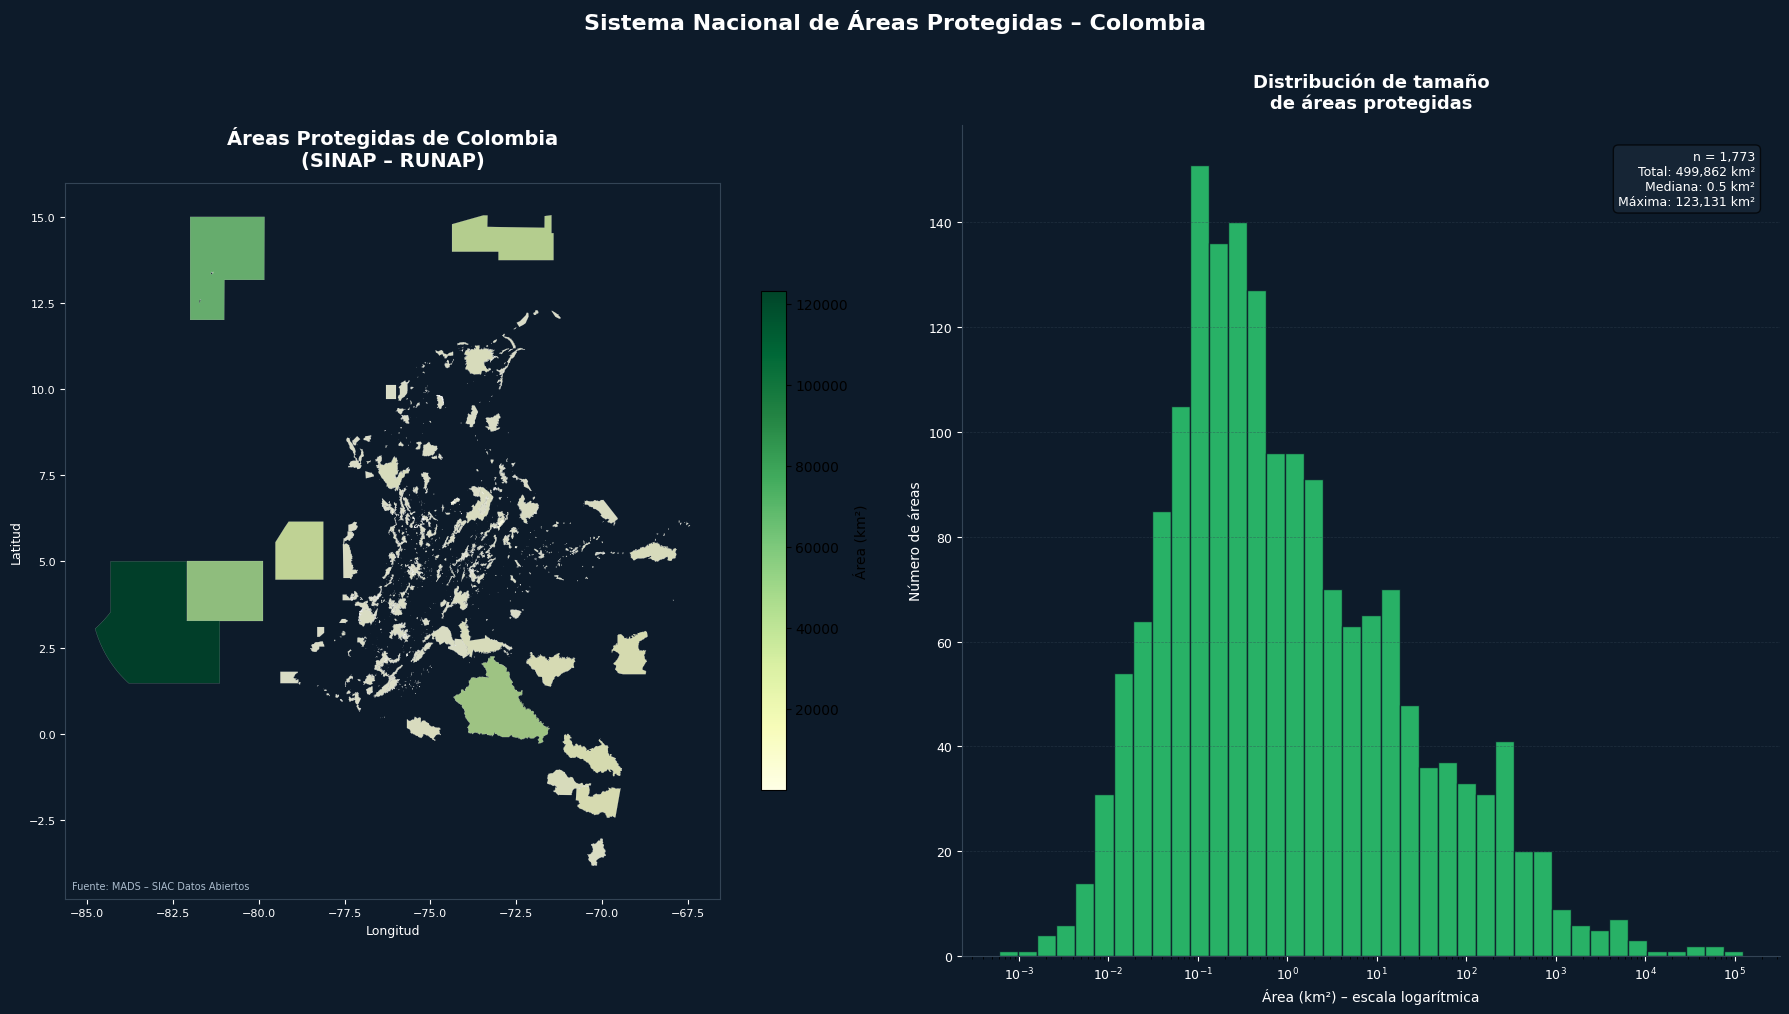

Mapa guardado en: c:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\2025\Outputs\Output1\Stress Test\3.Data\Scripts Python\scripts_python\data\areas_protegidas\areas_protegidas_mapa.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor("#0d1b2a")

# --- Mapa ---
ax_map = axes[0]
ax_map.set_facecolor("#0d1b2a")
if categoria_col and gdf[categoria_col].nunique() <= 20:
    categories = gdf[categoria_col].unique()
    cmap = plt.get_cmap("tab20", len(categories))
    cat_to_color = {cat: cmap(i) for i, cat in enumerate(categories)}
    gdf.plot(ax=ax_map, color=gdf[categoria_col].map(cat_to_color),
             edgecolor="white", linewidth=0.15, alpha=0.85)
    patches = [mpatches.Patch(color=cat_to_color[c], label=str(c)[:40]) for c in categories]
    ax_map.legend(handles=patches, loc="lower left", fontsize=6,
                  framealpha=0.3, facecolor="#1a2a3a", labelcolor="white",
                  title=categoria_col, title_fontsize=7)
else:
    gdf.plot(ax=ax_map, column="area_km2", cmap="YlGn",
             edgecolor="white", linewidth=0.1, alpha=0.85, legend=True,
             legend_kwds={"label": "Área (km²)", "shrink": 0.6})

ax_map.set_title("Áreas Protegidas de Colombia\n(SINAP – RUNAP)",
                 fontsize=14, fontweight="bold", color="white", pad=12)
ax_map.set_xlabel("Longitud", color="white", fontsize=9)
ax_map.set_ylabel("Latitud",  color="white", fontsize=9)
ax_map.tick_params(colors="white", labelsize=8)
for spine in ax_map.spines.values():
    spine.set_edgecolor("#334455")
ax_map.annotate("Fuente: MADS – SIAC Datos Abiertos",
    xy=(0.01, 0.01), xycoords="axes fraction", fontsize=7, color="#aabbcc", va="bottom")

# --- Histograma ---
ax_hist = axes[1]
ax_hist.set_facecolor("#0d1b2a")
area_vals = gdf["area_km2"].dropna()
area_vals = area_vals[area_vals > 0]
bins = np.logspace(np.log10(area_vals.min()), np.log10(area_vals.max()), 40)
ax_hist.hist(area_vals, bins=bins, color="#2ecc71", edgecolor="#0d1b2a", alpha=0.85)
ax_hist.set_xscale("log")
ax_hist.set_xlabel("Área (km²) – escala logarítmica", color="white", fontsize=10)
ax_hist.set_ylabel("Número de áreas", color="white", fontsize=10)
ax_hist.set_title("Distribución de tamaño\nde áreas protegidas",
                  fontsize=13, fontweight="bold", color="white", pad=12)
ax_hist.tick_params(colors="white", labelsize=9)
ax_hist.spines["bottom"].set_color("#334455")
ax_hist.spines["left"].set_color("#334455")
ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)
ax_hist.grid(axis="y", color="#334455", linestyle="--", linewidth=0.5, alpha=0.5)
ax_hist.text(0.97, 0.97,
    f"n = {len(gdf):,}\nTotal: {gdf['area_km2'].sum():,.0f} km²\n"
    f"Mediana: {area_vals.median():,.1f} km²\nMáxima: {area_vals.max():,.0f} km²",
    transform=ax_hist.transAxes, fontsize=9, color="white", va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a2a3a", alpha=0.7))

plt.suptitle("Sistema Nacional de Áreas Protegidas – Colombia",
             fontsize=16, fontweight="bold", color="white", y=1.01)
plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, "areas_protegidas_mapa.png")
plt.savefig(out_png, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Mapa guardado en:", out_png)